In [1]:
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git
#!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import torch
import numpy as np

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
#вспомогательная функция для визуализации
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()


In [3]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Planetoid', name='CiteSeer', transform=NormalizeFeatures())

Processing...
Done!


Выведу основные характеристики графа.

In [4]:
print()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('===========================================================================================================')

# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: CiteSeer():
Number of graphs: 1
Number of features: 3703
Number of classes: 6

Data(x=[3327, 3703], edge_index=[2, 9104], y=[3327], train_mask=[3327], val_mask=[3327], test_mask=[3327])
Number of nodes: 3327
Number of edges: 9104
Average node degree: 2.74
Number of training nodes: 120
Training node label rate: 0.04
Has isolated nodes: True
Has self-loops: False
Is undirected: True


Использую слои GCN из torch_geometric.

In [ ]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F


class GCN(torch.nn.Module):
    def __init__(self, hidden_channels1, hidden_channels2):
        super().__init__()
        torch.manual_seed(123456)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels1)
        self.conv2 = GCNConv(hidden_channels1, hidden_channels2)
        self.conv3 = GCNConv(hidden_channels2, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index)
        return x

model1 = GCN(hidden_channels1 = 32, hidden_channels2 = 16)
print(model1)

GCN(
  (conv1): GCNConv(3703, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(16, 6)
)


Визуализирую граф (пока не обучая сеть GCN).

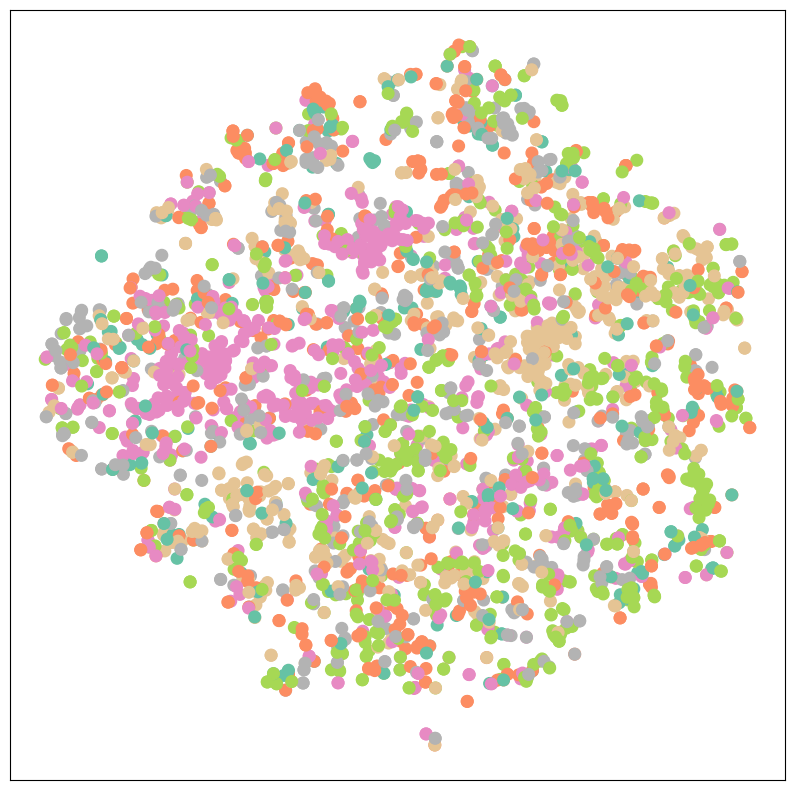

In [ ]:
model1 = GCN(hidden_channels1 = 32, hidden_channels2 = 16)
model1.eval()

out = model1(data.x, data.edge_index)
visualize(out, color=data.y)

Переиспользую кусочки кода с обучением из практического ноутбука. Буду подбирать параметр lr.

In [ ]:
from IPython.display import Javascript  # Restrict height of output cell.
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

#обозначаю параметры для перебора
lr = [0.1, 0.01, 0.001]
weight_decay = [5e-3, 5e-4, 5e-5]
best_lr = 0
best_weight_decay = 0
max_acc = 0
criterion = torch.nn.CrossEntropyLoss()

#функции train, validate и test
def train():
  model.train()
  optimizer.zero_grad()
  out = model(data.x, data.edge_index)
  loss = criterion(out[data.train_mask], data.y[data.train_mask])
  loss.backward()
  optimizer.step()
  return loss

#валидация
def validate():
  model.eval()
  out = model(data.x, data.edge_index)
  val_pred = out.argmax(dim=1)  # Use the class with highest probability.
  test_correct = val_pred[data.val_mask] == data.y[data.val_mask]  # Check against ground-truth labels.
  test_acc = int(test_correct.sum()) / int(data.val_mask.sum())  # Derive ratio of correct predictions.
  return test_acc

def test():
  model.eval()
  out = model(data.x, data.edge_index)
  pred = out.argmax(dim=1)  # Use the class with highest probability.
  test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
  test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
  return test_acc

<IPython.core.display.Javascript object>

Реализую перебор параметров с подсчетом accuracy на валидационной выборке.

In [ ]:
model = GCN(hidden_channels1 = 32, hidden_channels2 = 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1, weight_decay=5e-4)
for epoch in range(1, 101):
  loss = train()
  #if epoch % 40 == 0:
    #print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

val_acc = validate()
print(f'Val Accuracy: {val_acc:.4f}')

Val Accuracy: 0.6340


In [ ]:
model = GCN(hidden_channels1 = 32, hidden_channels2 = 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
for epoch in range(1, 101):
  loss = train()
  #if epoch % 40 == 0:
    #print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

val_acc = validate()
print(f'Val Accuracy: {val_acc:.4f}')

Val Accuracy: 0.6640


In [ ]:
model = GCN(hidden_channels1 = 32, hidden_channels2 = 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
for epoch in range(1, 101):
  loss = train()
  #if epoch % 40 == 0:
    #print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

val_acc = validate()
print(f'Val Accuracy: {val_acc:.4f}')

Val Accuracy: 0.5880


По итогам метрик на валидационной выборке оставлю lr = 0.01.

In [ ]:
model = GCN(hidden_channels1 = 32, hidden_channels2 = 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
for epoch in range(1, 201):
  loss = train()
  if epoch % 40 == 0:
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Epoch: 040, Loss: 0.8390
Epoch: 080, Loss: 0.3480
Epoch: 120, Loss: 0.2620
Epoch: 160, Loss: 0.1866
Epoch: 200, Loss: 0.1847
Test Accuracy: 0.6720


Визуализирую полученные результаты.

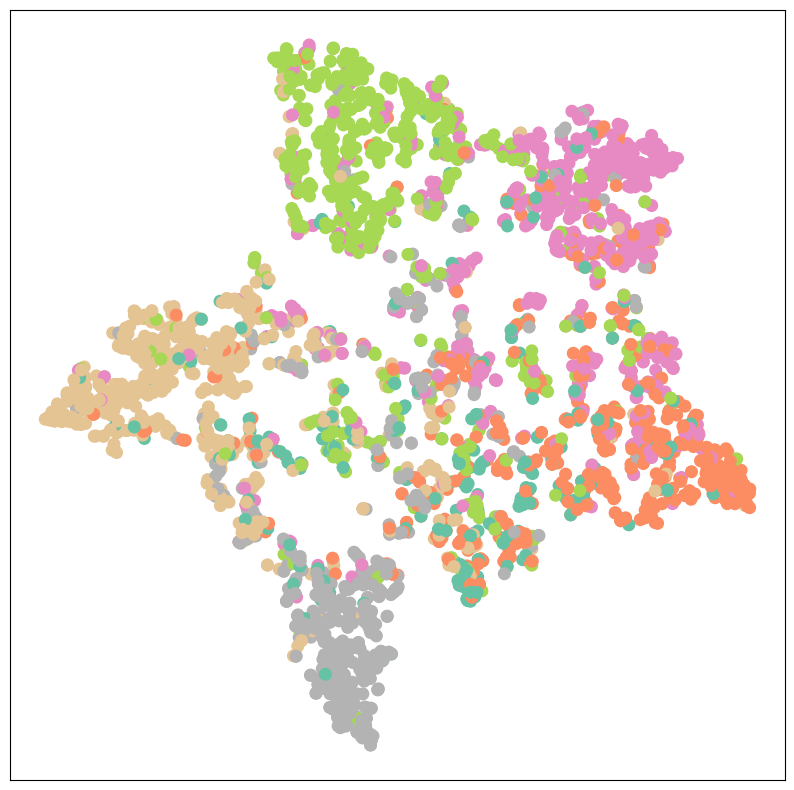

In [ ]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

По результатам визуализации можно отметить фигуру, похожую на пятиконечную звезду (с выделением каждого из множеств на острие звезды). Однако, также есть и достаточное количество точек в центре, которые достаточно трудно отнести к тому или иному множеству (даже взглядом человека).

**Реализация собственного слоя GCN**

In [5]:
#использую категориальную кросс-энтропию
def loss_func(y, p, eps = 1e-8):
  return -np.mean(np.sum(y * np.log(p + eps), axis = 1))

#вычисляю матрицу степеней вершин
def degree_m(A):
  D = np.diag(np.sum(A, axis = 1))
  return D

#лапласиан графа L = I - D^(-1/2)AD^(-1/2)
#для ускорения можно апроксимировать многочленами Чебышева
def graph_lapl(A):
  D = degree_m(A)
  D_sqrt = np.sqrt(D)
  #использую pinv для апроксимации вследствие сингулярности матрицы
  D_inv = np.linalg.pinv(D_sqrt)
  I = np.identity(len(A))
  return I - np.dot(D_inv, np.dot(A, D_inv))

#реализую также relu и softmax для входных массивов
def relu(x):
  return x * (x > 0)
def softmax(x):
  exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
  return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

class myGCNConv:
  #конструктор
  def __init__(self, in_params, out_params):
    self.W = np.random.randn(in_params, out_params) #инициализация матрицы весов
    self.b = np.zeros((1, out_params)) #матрицы смещений
    self.A, self.X = None, None #матрицы данных и смежности

  #прямой проход
  def forward(self, X, A):
    self.A = A
    self.X = X
    L = graph_lapl(self.A) #вычисление лапласиана
    return np.dot(np.dot(L, self.X), self.W) + self.b

  #обратный проход
  def backward(self, er, lr):
    L = graph_lapl(self.A)
    out_data = np.dot(self.X.T, L) #вычисление выходных данных
    gradW = np.dot(out_data, er) #вычисление ошибки W
    gradb = np.sum(er, axis = 0, keepdims = True) #вычисление ошибки b
    #изменение матриц весов и смещений
    self.W -= lr * gradW
    self.b -= lr * gradb
    return np.dot(L.T, np.dot(er, self.W.T))

In [15]:
import torch.nn.functional as F
class myGCN:
    def __init__(self, hidden_channels1, hidden_channels2):
        self.conv1 = myGCNConv(dataset.num_features, hidden_channels1)
        self.conv2 = myGCNConv(hidden_channels1, hidden_channels2)
        self.conv3 = myGCNConv(hidden_channels2, dataset.num_classes)

    #прямой проход
    def forward(self, x, A):
        x = self.conv1.forward(x, A)
        x = relu(x)
        #x = F.dropout(x, p=0.5)
        x = self.conv2.forward(x, A)
        x = relu(x)
        #x = F.dropout(x, p=0.5)
        x = self.conv3.forward(x, A)
        return softmax(x)

    #обратное распространение ошибки по всем слоям
    def backward(self, y, y_p, alpha = 0.01):
      er = (y_p - y) / y.shape[0]
      gradConv3 = self.conv3.backward(er, alpha)
      gradConv2 = self.conv2.backward(gradConv3, alpha)
      gradConv1 = self.conv1.backward(gradConv2, alpha)
      return gradConv1, gradConv2, gradConv3

In [16]:
#подготовка данных
adj_m = np.zeros((data.num_nodes, data.num_nodes))
edge_index = data.edge_index.numpy()
adj_m[edge_index[0], edge_index[1]] = 1
adj_m[edge_index[1], edge_index[0]] = 1
A = adj_m
y = data.y.numpy()
num_labels = len(np.unique(data.y))
y = np.eye(num_labels)[y]

In [17]:
myGCN = myGCN(hidden_channels1 = 16, hidden_channels2 = 16)
for epoch in range(1, 51):
    out = myGCN.forward(data.x, A)
    loss = loss_func(y[data.train_mask], out[data.train_mask])
    if epoch % 5 == 0:
      print(f'epoch: {epoch}, loss = {loss}')
    myGCN.backward(y, out, alpha = 0.1)
print("train finished")

epoch: 5, loss = 3.06798272171298
epoch: 10, loss = 2.7501146268970142
epoch: 15, loss = 2.5740879050752
epoch: 20, loss = 2.4334165792587092
epoch: 25, loss = 2.328853887782888
epoch: 30, loss = 2.2491499886915203
epoch: 35, loss = 2.1859217817533914
epoch: 40, loss = 2.132859550319392
epoch: 45, loss = 2.0888990386703683
epoch: 50, loss = 2.054159812025174
train finished


Из результатов можно отметить:

1. Более долгое обучение собственной сети. Связываю это с использованием дорогостоящей операции свертки (как вариант решения, в различных источниках предлагают использовать апроксимацию с помощью многочленов Чебышева).
2. Больший первоначальный loss (возможно, используется немного другая функция вычисления ошибок + изначально матрицы весов и смещений инициализируются случайными значениями из нормального распределения).

При этом хотелось бы отметить монотонное убывание loss, что свидетельствует о корректности обучения сети.